First 5 Rows
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Shape
(35, 2)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes
None

Statistics
       YearsExperience         Salary
count        35.000000      35.000000
mean          6.308571   83945.600000
std           3.618610   32162.673003
min           1.100000   37731.000000
25%           3.450000   57019.000000
50%           5.300000   81363.000000
75%           9.250000  113223.500000
max          13.500000  139465.000000

Missing Values
YearsExperience    0
Salary             0
dtype: int64

Duplicate Rows
0


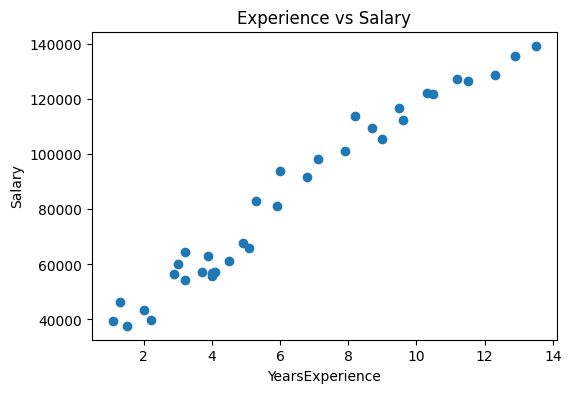


Correlation Matrix
                 YearsExperience    Salary
YearsExperience         1.000000  0.982427
Salary                  0.982427  1.000000


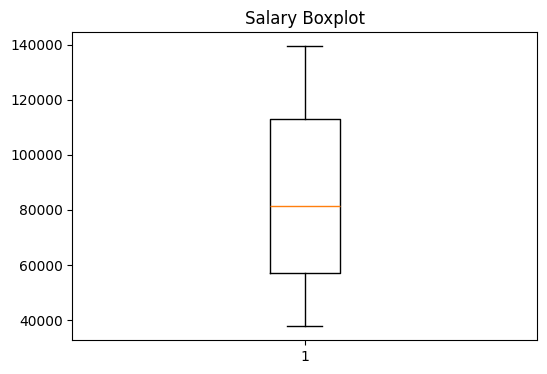


Model Evaluation
MAE : 5879.25652987993
MSE : 42353175.93704311
RMSE: 6507.931771080817
R2 Score: 0.9175320027998447

Intercept
23956.635563250442

Coefficients
[    0.         10663.64799196  -147.07674975]

Predicted Salary for 7 Years Experience = 91395.41076912053


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


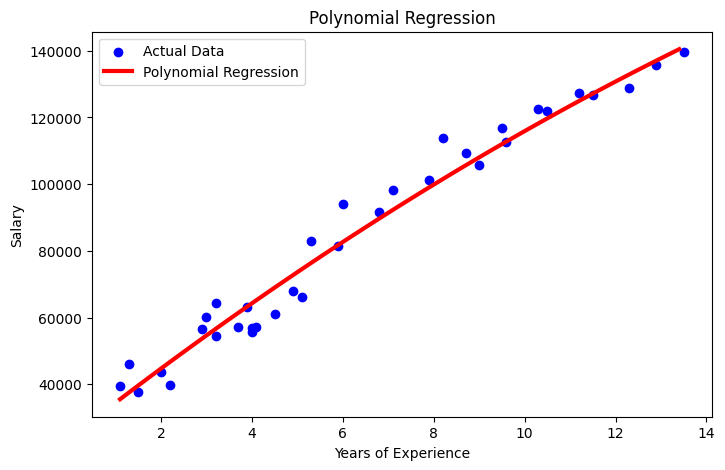

In [ ]:
# ==============================
# POLYNOMIAL REGRESSION PROJECT
# Salary_Data.csv
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("Salary.csv")

# ==============================
# Basic Inspection
# ==============================

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nInformation")
print(df.info())

print("\nStatistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

# ==============================
# Missing Value Handling
# ==============================

df.fillna(df.mean(numeric_only=True), inplace=True)

# ==============================
# EDA
# ==============================

plt.figure(figsize=(6,4))
plt.scatter(df["YearsExperience"], df["Salary"])
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

# Correlation

print("\nCorrelation Matrix")
print(df.corr(numeric_only=True))

# ==============================
# Outlier Detection
# ==============================

plt.figure(figsize=(6,4))
plt.boxplot(df["Salary"])
plt.title("Salary Boxplot")
plt.show()

# ==============================
# Feature Engineering
# ==============================
# Not Required

# ==============================
# Encoding
# ==============================
# Not Required

# ==============================
# Feature Scaling
# ==============================
# Not Required

# ==============================
# Split Features and Target
# ==============================

X = df[["YearsExperience"]]
y = df["Salary"]

# ==============================
# Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==============================
# Polynomial Feature Transformation
# ==============================

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ==============================
# Train Model
# ==============================

model = LinearRegression()

model.fit(X_train_poly, y_train)

# ==============================
# Prediction
# ==============================

y_pred = model.predict(X_test_poly)

# ==============================
# Evaluation
# ==============================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==============================
# Coefficients
# ==============================

print("\nIntercept")
print(model.intercept_)

print("\nCoefficients")
print(model.coef_)

# ==============================
# Predict New Salary
# ==============================

experience = 7

experience_poly = poly.transform([[experience]])

predicted_salary = model.predict(experience_poly)

print("\nPredicted Salary for", experience, "Years Experience =",
      predicted_salary[0])

# ==============================
# Polynomial Curve Visualization
# ==============================

X_grid = np.arange(
    X.min().values[0],
    X.max().values[0],
    0.1
).reshape(-1,1)

X_grid_poly = poly.transform(X_grid)

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color="blue",
    label="Actual Data"
)

plt.plot(
    X_grid,
    model.predict(X_grid_poly),
    color="red",
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression")
plt.legend()

plt.show()